# UQ Data Prep Notebook 
### This notebook contains code to fit ChemTab model and generate encoded data
#### Amol Salunkhe

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge, LinearRegression
from sklearn import gaussian_process
from sklearn.gaussian_process import GaussianProcessRegressor
import scipy.optimize
from sklearn.utils.optimize import _check_optimize_result
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, RationalQuadratic, ExpSineSquared
import time
from sklearn.decomposition import PCA, SparsePCA
%matplotlib inline
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing
import tensorflow_probability as tfp
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers, activations, initializers, constraints, Sequential
from tensorflow.keras.constraints import UnitNorm, Constraint
import random
import sys

# libraries and data
plt.style.use('seaborn')
encoding_dim = 4
cpv_cols = ["Cpv"+str(i+1) for i in range (encoding_dim)]

# Load and prepare data

In [2]:
class PositiveLogNormal:
    def __init__(self):
        self.max_value = 0
        return
    
    def set_max_value(self,max_value):
        self.max_value = max_value
        return 
    
    def get_max_value(self):
        return self.max_value
        
    def fit_transform(self,data):
        temp = pd.DataFrame(data=data, columns=["target"])
        max_value = temp["target"].max()
        self.set_max_value(max_value)
        #2*self.set_max_value --> to account for max that may be out of this dataset
        temp['transfomed'] = temp.apply(lambda row: np.log1p((row.target + 2*self.max_value)), axis=1)
        transfomed_data = temp['transfomed'].values
        transfomed_data = transfomed_data.reshape(transfomed_data.shape[0], 1)
        return transfomed_data
    
    def inverse_transform(self,transformeddata):
        #todo: complete this
        temp = pd.DataFrame(data=transformeddata, columns=["target"])
        temp['inverse'] = temp.apply(lambda row:  np.expm1((row.target)) - 2*self.max_value, axis=1)
        data = temp['inverse'].values
        data = data.reshape(data.shape[0], 1)
        return data

In [3]:
class WeightsOrthogonalityConstraint (Constraint):
    def __init__(self, encoding_dim, weightage = 1.0, axis = 0):
        self.encoding_dim = encoding_dim
        self.weightage = weightage
        self.axis = axis
        
    def weights_orthogonality(self, w):
        if(self.axis==1):
            w = tf.transpose(w)
        if(self.encoding_dim > 1):
            m = tf.matmul(tf.transpose(w), w) - tf.eye(self.encoding_dim)
            return self.weightage * tf.math.sqrt(tf.math.reduce_sum(tf.math.square(m)))
        else:
            m = tf.math.reduce_sum(w ** 2) - 1.
            return m

    def __call__(self, w):
        return self.weights_orthogonality(w)
    
    def get_config(self):
        return {'axis':self.axis,'weightage':self.weightage,'encoding_dim':self.encoding_dim}
    

class UncorrelatedFeaturesConstraint (Constraint):

    def __init__(self, encoding_dim, weightage=1.0):
        self.encoding_dim = encoding_dim
        
        self.weightage = weightage

        self.covariance = None
        
    def get_covariance(self, x):
        x_centered_list = []

        for i in range(self.encoding_dim):
            x_centered_list.append(x[:, i] - tf.math.reduce_mean(x[:, i]))

        x_centered = tf.stack(x_centered_list)
        
        covariance = tf.matmul(x_centered, tf.transpose(x_centered)) / tf.cast(x_centered.get_shape()[0], tf.float32)
        #covariance = tf.matmul(x_centered, tf.transpose(x_centered)) / tf.cast(tf.shape(x_centered)[0], tf.float32)

        return covariance

    # Constraint penalty
    def uncorrelated_feature(self, x):
        if(self.encoding_dim <= 1):
            return 0.0
        else:
            output = tf.math.reduce_sum(tf.math.square(self.covariance - tf.math.multiply(self.covariance, tf.eye(self.encoding_dim))))
            return output

    def __call__(self, x):
        self.covariance = self.get_covariance(x)
        return self.weightage * self.uncorrelated_feature(x)
    
    def get_config(self):
        return {'weightage': self.weightage, 'encoding_dim':self.encoding_dim}


In [4]:
#read the data into a dataframe
df = pd.read_csv('NewData_flames_data_with_L1_L2_errors_CH4-AIR_without_trimming(SouSpec_Included).txt')



#create an integer representation of the flame-id and add to the data frame
df['flame_key_int'] = df[' flame_key'].mul(10000000).astype(int)

#create an integer representation of the flame-id and add to the data frame
df['X_int'] = df['X'].mul(10000000).astype(int)

#create an integer to determine if the flame is included by the framework in the manifold creation and reverselookup
#framework_untrimmed_flameids = [0.00115982, 0.00122087, 0.00128512, 0.00135276, 0.00142396, 0.0014989, 0.00157779, 0.00166083, 0.00174825, 0.00184026, 0.00193711, 0.00203907, 0.00214639, 0.00225936, 0.00237827, 0.01]

framework_untrimmed_flameids = ['2.0276547153583627E-4', '2.1343733845877503E-4', '2.2467088258818426E-4', '2.3649566588229923E-4', '2.4894280619189394E-4', '2.6204505914936203E-4', '2.7583690436774953E-4', '2.903546361765785E-4', '3.056364591332405E-4', '3.2172258856130585E-4', '3.3865535638032194E-4', '0.0032353354497370902']


framework_untrimmed_flame_key_ints = [int(float(framework_untrimmed_flameids[i])*10000000) for i in range(len(framework_untrimmed_flameids))]

def isFlame_included(flame_key_int):
    if flame_key_int in framework_untrimmed_flame_key_ints:
        ret_val = 1
    else:
        ret_val = 0
    return ret_val

df['is_flame_included_by_framework'] = df['flame_key_int'].map(lambda x: isFlame_included(x))

df['souener_deciles'] = pd.qcut(df['souener'],10)


cut_labels = ['0.0 - 0.11', '0.11 - 0.22', '0.22 - 0.33', '0.33 - 0.44', '0.44 - 0.55', '0.55 - 0.66','0.66 - 0.77', '0.77 - 0.88', '0.88 - 0.99', '0.99 - 1.1']
cut_bins = np.linspace(0, 1.1, 11) 
#df['Xpos_bins'] = pd.cut(df['Xpos'], bins=cut_bins, labels=cut_labels)
df['X_bins'] = pd.cut(df['X'], bins=cut_bins, labels=cut_labels)


In [5]:
framework_included_flames_int = df[df['is_flame_included_by_framework'] == 1]['flame_key_int'].unique()

framework_excluded_flames_int = df[df['is_flame_included_by_framework'] == 0]['flame_key_int'].unique()

all_flames_int = df['flame_key_int'].unique()

def getTrainTestFlames(method):
    
    training_flames_int = []

    testing_flames_int = []

    if(method == "frameworkincludedexcludedequalsplit"):
    
        for x in framework_included_flames_int:
            training_flames_int.append(x)

        for x in framework_excluded_flames_int[::2]:
            training_flames_int.append(x)

        for x in framework_included_flames_int:
            testing_flames_int.append(x)

        for x in framework_excluded_flames_int[1::2]:
            testing_flames_int.append(x)
    
    elif(method == "frameworkincludedtrainexcludedtest"):
        for x in framework_included_flames_int:
            training_flames_int.append(x)

        for x in framework_excluded_flames_int:
            testing_flames_int.append(x)
    
    elif(method == "frameworkincludedtrainexcludedandincludedtest"):
        for x in framework_included_flames_int:
            training_flames_int.append(x)

        for x in framework_included_flames_int:
            testing_flames_int.append(x)

        for x in framework_excluded_flames_int:
            testing_flames_int.append(x)
            
    else:
        for x in all_flames_int:
            training_flames_int.append(x)
            testing_flames_int.append(x)
    
    df_training = df[df['flame_key_int'].isin(training_flames_int)]

    df_testing = df[df['flame_key_int'].isin(testing_flames_int)]
    
    return df_training,df_testing


def getTrainTestData(method):
    
    method_parts = method.split('_')

    df_trainingFlames, df_testingFlames = getTrainTestFlames(method_parts[1])

    if method_parts[0] == "ZmixCpv":
        X_train = df_trainingFlames [["Zmix","Cpv"]].values
        
        Y_train = df_trainingFlames [["souener"]].values
        
        X_test = df_testingFlames [["Zmix","Cpv"]].values
        
        Y_test = df_testingFlames [["souener"]].values
    
    elif method_parts[0] == "ZmixPCA":
        X_train = df_trainingFlames [zmix_pca_dim_cols].values
        
        Y_train = df_trainingFlames [["souener"]].values
        
        X_test = df_testingFlames [zmix_pca_dim_cols].values
        
        Y_test = df_testingFlames [["souener"]].values
        
    elif method_parts[0] == "SparsePCA":
        X_train = df_trainingFlames [sparse_pca_dim_cols].values
        
        Y_train = df_trainingFlames [["souener"]].values
        
        X_test = df_testingFlames [sparse_pca_dim_cols].values
        
        Y_test = df_testingFlames [["souener"]].values
    
    elif method_parts[0] == "PurePCA":
        X_train = df_trainingFlames [pure_pca_dim_cols].values
        
        Y_train = df_trainingFlames [["souener"]].values
        
        X_test = df_testingFlames [pure_pca_dim_cols].values
        
        Y_test = df_testingFlames [["souener"]].values
        
    else:
        X_train = df_trainingFlames [icovariates].values
        
        Y_train = df_trainingFlames [["souener"]].values
        
        X_test = df_testingFlames [icovariates].values
        
        Y_test = df_testingFlames [["souener"]].values
    
    return X_train,Y_train,X_test,Y_test

In [6]:
def computeError (Y_pred, Y_test):
    evaluation_df_1 = pd.DataFrame()

    evaluation_df_1['souener'] = Y_test.flatten()

    evaluation_df_1['souener_pred'] = Y_pred.flatten()

    evaluation_df_1['souener_pred_L1'] = evaluation_df_1['souener'] - evaluation_df_1['souener_pred'] 

    evaluation_df_1['souener_pred_L2'] = evaluation_df_1['souener_pred_L1'] * evaluation_df_1['souener_pred_L1']
    
    evaluation_df_1['souener_pred_L1Percent'] = ((evaluation_df_1['souener'] - evaluation_df_1['souener_pred'])/evaluation_df_1['souener']) 
    
    TotalAbsoluteError = evaluation_df_1['souener_pred_L1'].abs().sum()

    TotalSquaredError = evaluation_df_1['souener_pred_L2'].abs().sum()
    
    MeanAbsoluteError = evaluation_df_1['souener_pred_L1'].abs().sum()/evaluation_df_1['souener_pred_L1'].abs().count()

    MeanSquaredError = evaluation_df_1['souener_pred_L2'].abs().sum()/evaluation_df_1['souener_pred_L2'].abs().count()
    
    NumPoints = evaluation_df_1['souener_pred_L1Percent'].abs().count()
    
    MeanPercentageError = evaluation_df_1['souener_pred_L1Percent'].abs().sum()/NumPoints
    
    return [MeanAbsoluteError,TotalAbsoluteError,MeanPercentageError,MeanSquaredError,TotalSquaredError,NumPoints]

def printError (err):
    MeanAbsoluteError = err[0]
    TotalAbsoluteError = err[1]
    MeanPercentageError = err[2]
    MeanSquaredError = err[3]
    TotalSquaredError = err[4]
    NumPoints = err[5]
    print ('Total Absolute Error: ', TotalAbsoluteError)
    print ('Mean Absolute Error: ', MeanAbsoluteError)
    print ('Mean Percentage Error: ', MeanPercentageError)
    print ('Total Squared Error: ', TotalSquaredError)
    print ('Mean Squared Error: ', MeanSquaredError)
    print ('Number of Points: ', NumPoints)

def computeAndPrintError(Y_pred, Y_test):    
    err = computeError (Y_pred, Y_test)
    printError (err)
    return err

def computeErrorAcrossDependents(Y_pred_df, Y_test_df):    
    err_data = []
    for dependent in dependents:
        Y_pred = Y_pred_df[dependent].values
        Y_test = Y_test_df[dependent].values
        err = computeError (Y_pred, Y_test)
        err.insert(0,dependent)
        err_data.append(err)
    err_df = pd.DataFrame(data=err_data, columns=["Dependent","Mean ABS","Total ABS","Mean Pct Err","Mean SSE","Total SSE", "#Pts" ])
    err_df.drop(columns=["Mean Pct Err","Mean SSE","Total SSE"], inplace=True)
    return err_df


## DNN Method Support Functions

In [7]:
def getResiduals(Y_test,Y_pred):
    evaluation_df_1 = pd.DataFrame()

    evaluation_df_1['actual'] = Y_test.flatten()

    evaluation_df_1['prediction'] = Y_pred.flatten()

    evaluation_df_1['res'] = evaluation_df_1['actual'] - evaluation_df_1['prediction'] 
   
    return evaluation_df_1['res'].values


In [8]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Error [All Souspecs + Souener]')
    plt.legend()
    plt.grid(True)
    
   

In [9]:
def plot_loss_physics_and_regression(history):
    f = plt.figure(figsize=(10,3))
    ax = f.add_subplot(121)
    ax2 = f.add_subplot(122)
    
    ax.plot(history.history['prediction_loss'], label='loss')
    ax.plot(history.history['val_prediction_loss'], label='val_loss')
    ax.set_title('Souener Prediction Loss')
    ax.set(xlabel='Epoch', ylabel='Souener Error')
    ax.legend()

    ax2.plot(history.history['physics_loss'], label='loss')
    ax2.plot(history.history['val_physics_loss'], label='val_loss')
    ax2.set_title('Physics Loss')
    ax2.set(xlabel='Epoch', ylabel='Physics Error')
    ax2.legend()
        

In [10]:
# patient early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=45)
from tensorflow.keras import regularizers, activations, initializers, constraints, Sequential
from tensorflow.keras.constraints import UnitNorm, Constraint
from tensorflow.keras import backend as K

In [11]:
num_principal_components = 5

pca = PCA(n_components=num_principal_components)

icovariates = []
for c in df.columns:
    if c[0:2] == 'Yi':
        icovariates.append(c)

X = df[icovariates].values
        
pure_pca_dim_cols = ["PURE_PCA_"+str(i+1) for i in range(num_principal_components)]

pca.fit_transform(X)
        
df_pure_pca = pd.DataFrame(pca.transform(X), columns = pure_pca_dim_cols)
        
df = pd.concat([df,df_pure_pca], axis=1)

zmix_pca_dim_cols = ["Zmix_PCA_"+str(i+1) for i in range(num_principal_components)]

wopt = np.array([0.25131806468584, 1.0, 0.0, 0.0, 0.05926499970012948, 0.11189834407236524, 0.03053739933116691, 0.05926499970012948, 0.0, 0.07742283372149472, 0.14371856860332313, 0.14371856860332313, 0.20112514400193687, 1.0, 0.0, 0.0, 0.03473494419333629, 0.06713785861443991, 0.09743596683886535, 0.09743596683886535, 0.12582790137651187, 0.04027033873046593, 0.07742283372149472, 0.11180607885607882, 0.14371856860332313, 0.17341738612784788, 0.20112514400193687, 0.024566681794273966, 0.04795526192839207, 0.04795526192839207, 0.0, 0.06713048065088474, 0.12581494366075874, 0.17755300484072126, 0.034730994502665966, 0.0, 0.0, 0.0, 0.03249947443158002, 0.0, 0.0372961080230628, 0.07191024382448291, 0.024564706019978535, 0.023426986426879046, 0.023426986426879046, 0.023426986426879046, 0.0, 0.16374935944566987, 0.18286442054789118, 0.07024850027715426, 0.09152158240065958, 0.0, 0.0] , dtype=float)

w = wopt[:,np.newaxis]

# center the data
Xcenter = X - np.mean(X)

A = np.cov(X.T)

# calculate A - ww^TA
L = A - np.dot(np.dot(w,w.T),A)

# get the first eigen vector
values,vectors = np.linalg.eig(L)

vectors = np.real(vectors)

values = np.real(values)

df_zmix_pca = pd.DataFrame(df['flame_key_int'], columns = ['flame_key_int'])

df_zmix_pca[zmix_pca_dim_cols[0]] = Xcenter.dot(wopt)

for i in range(len(zmix_pca_dim_cols)-1):
    df_zmix_pca[zmix_pca_dim_cols[i+1]] = Xcenter.dot(vectors.T[i])

df_zmix_pca = pd.DataFrame(pca.transform(X), columns = zmix_pca_dim_cols)
        
df = pd.concat([df,df_zmix_pca], axis=1)

In [12]:
# demonstrate data normalization with sklearn
from sklearn.preprocessing import QuantileTransformer,MinMaxScaler

icovariates = []
for c in df.columns:
    if c[0:2] == 'Yi':
        icovariates.append(c)

dependents = ["souener","souspecO2", "souspecCO", "souspecCO2", "souspecH2O", "souspecOH", "souspecH2", "souspecCH4"]
phytrackers = ["X_bins","flame_key_int"]

def train_test_split_on_flamekey(df, train_portion=0.5, seed=0):
    random.seed(seed)
    flame_keys = list(set(df['flame_key_int']))
    random.shuffle(flame_keys)
    train_set_keys = flame_keys[:int(len(flame_keys)*train_portion)]
    test_set_keys = flame_keys[int(len(flame_keys)*train_portion):]
    print('train_set_keys: ', train_set_keys)
    print('test_set_keys: ', test_set_keys)

    train_set = df[np.isin(df['flame_key_int'], train_set_keys)]
    test_set = df[np.isin(df['flame_key_int'], test_set_keys)]
    print('train: ', train_set['flame_key_int'].unique()[:5])
    print('test: ', test_set['flame_key_int'].unique()[:5])
    return train_set, test_set    

def getDataSet(ipscaler="MinMaxScaler",opscaler="MinMaxScaler", split_strategy="points", train_portion=0.8):
    if split_strategy =="points":
        train_df= df.sample(frac=train_portion,random_state=0)
        test_df = df.drop(train_df.index)   
    else:
        train_df, test_df = train_test_split_on_flamekey(df, train_portion=0.8, seed=0)
    
    #Training
    X_allSpecies_train = train_df[icovariates].values
    X_zmix_pca_train = train_df[zmix_pca_dim_cols].values
    X_pure_pca_train = train_df[pure_pca_dim_cols].values
    X_zmix_cpv_train = train_df[["Zmix", "Cpv"]].values
    Y_train = train_df[dependents].values
    Zmix_train = train_df["Zmix"].values
    Xpos_train = train_df["X"].values
    Xpos_bins_train = train_df["X_bins"].values
    flame_keys_train = train_df[" flame_key"].values
    flame_key_ints_train = train_df["flame_key_int"].values
    #Testing
    X_allSpecies_test = test_df[icovariates].values
    X_zmix_pca_test = test_df[zmix_pca_dim_cols].values
    X_pure_pca_test = test_df[pure_pca_dim_cols].values
    X_zmix_cpv_test = test_df[["Zmix", "Cpv"]].values
    Y_test = test_df[dependents].values
    Zmix_test = test_df["Zmix"].values
    Xpos_test = test_df["X"].values
    Xpos_bins_test = test_df["X_bins"].values
    flame_keys_test = test_df[" flame_key"].values
    flame_key_ints_test = test_df["flame_key_int"].values
        
        
    if ipscaler == "MinMaxScaler":
        inputScalerFunction = MinMaxScaler
    else:
        inputScalerFunction = QuantileTransformer
    
    if opscaler == "MinMaxScaler":
        outputScalerFunction = MinMaxScaler
    else:
        outputScalerFunction = QuantileTransformer
    
    
    # create scaler
    scaler_species = inputScalerFunction()
    # fit and transform in one step
    normalized_species_train = scaler_species.fit_transform(X_allSpecies_train)
    normalized_species_test = scaler_species.fit_transform(X_allSpecies_test)

    
    # create scaler
    scaler_zmixpca = inputScalerFunction()
    
    # fit and transform in one step
    normalized_zmixpca_train = scaler_zmixpca.fit_transform(X_zmix_pca_train)
    normalized_zmixpca_test = scaler_zmixpca.fit_transform(X_zmix_pca_test)

    scaler_souener = outputScalerFunction()#()#MinMaxScaler()
    
    # fit and transform in one step
    normalized_souener_train = scaler_souener.fit_transform(Y_train)
    normalized_souener_test = scaler_souener.fit_transform(Y_test)

    normalized_souener_train = normalized_souener_train
    normalized_souener_test = normalized_souener_test
    return {"scaler_species":scaler_species,"scaler_zmixpca":scaler_zmixpca,"scaler_souener":scaler_souener,\
            "X_zmix_pca_train":X_zmix_pca_train,"X_zmix_pca_test":X_zmix_pca_test,"X_zmix_pca_all":np.concatenate((X_zmix_pca_test,X_zmix_pca_train)),\
            "X_pure_pca_train":X_pure_pca_train,"X_pure_pca_test":X_pure_pca_test,"X_pure_pca_all":np.concatenate((X_pure_pca_test,X_pure_pca_train)),\
            "X_zmix_cpv_train":X_zmix_cpv_train,"X_zmix_cpv_test":X_zmix_cpv_test,"X_zmix_cpv_all":np.concatenate((X_zmix_cpv_test,X_zmix_cpv_train)),\
            "Zmix_train":Zmix_train,"Zmix_test":Zmix_test,"Zmix_all":np.concatenate((Zmix_test,Zmix_train)),\
            "normalized_species_train":normalized_species_train,"normalized_species_test":normalized_species_test,"normalized_species_all":np.concatenate((normalized_species_test,normalized_species_train)),\
            "Y_test":Y_test,"Y_train":Y_train,"Y_all":np.concatenate((Y_test,Y_train)),\
            "normalized_zmixpca_train":normalized_zmixpca_train,"normalized_zmixpca_test":normalized_zmixpca_test,"normalized_zmixpca_all":np.concatenate((normalized_zmixpca_test,normalized_zmixpca_train)),\
            "normalized_souener_train": normalized_souener_train,"normalized_souener_test":normalized_souener_test,"normalized_souener_all":np.concatenate((normalized_souener_test,normalized_souener_train)),\
            "Xpos_bins_train":Xpos_bins_train,"Xpos_bins_test":Xpos_bins_test,"Xpos_bins_all":np.concatenate((Xpos_bins_test,Xpos_bins_train)),\
            "flame_key_ints_train":flame_key_ints_train,"flame_key_ints_test":flame_key_ints_test,"flame_key_ints_all":np.concatenate((flame_key_ints_test,flame_key_ints_train)),\
            "Xpos_train":Xpos_train,"Xpos_test":Xpos_test,"Xpos_all":np.concatenate((Xpos_test,Xpos_train)),\
            "flame_keys_train":flame_keys_train,"flame_keys_test":flame_keys_test,"flame_keys_all":np.concatenate((flame_keys_test,flame_keys_train))}

In [13]:
getDataSet()['normalized_souener_train']

array([[0.47849165, 0.65913516, 0.649548  , ..., 0.23603479, 0.60941658,
        0.75677567],
       [0.04298956, 0.83696472, 0.17615188, ..., 0.34889032, 0.51429745,
        0.9282806 ],
       [0.09540206, 0.82483091, 0.29075748, ..., 0.31044297, 0.52158652,
        0.96176905],
       ...,
       [0.01382703, 0.84135337, 0.16761215, ..., 0.355619  , 0.45972467,
        0.99303085],
       [0.01534241, 0.84135111, 0.167615  , ..., 0.35561803, 0.45972749,
        0.99309535],
       [0.0160989 , 0.84134224, 0.16762597, ..., 0.35562137, 0.4597261 ,
        0.99305097]])

In [14]:
error_dict = {}

In [15]:
df.columns

Index(['X', 'YiCH4', 'YiH', 'YiO', 'YiO2', 'YiOH', 'YiH2O', 'YiHO2', 'YiH2O2',
       'YiC',
       ...
       'PURE_PCA_1', 'PURE_PCA_2', 'PURE_PCA_3', 'PURE_PCA_4', 'PURE_PCA_5',
       'Zmix_PCA_1', 'Zmix_PCA_2', 'Zmix_PCA_3', 'Zmix_PCA_4', 'Zmix_PCA_5'],
      dtype='object', length=132)

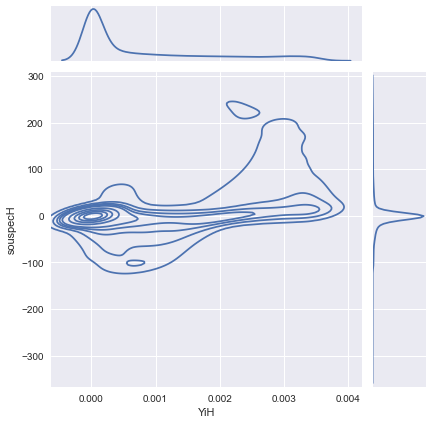

In [16]:
# 2D density + marginal distribution:
sns.jointplot(x=df.YiH, y=df.souspecH, kind='kde')

# ChemTab Implementation Architecture

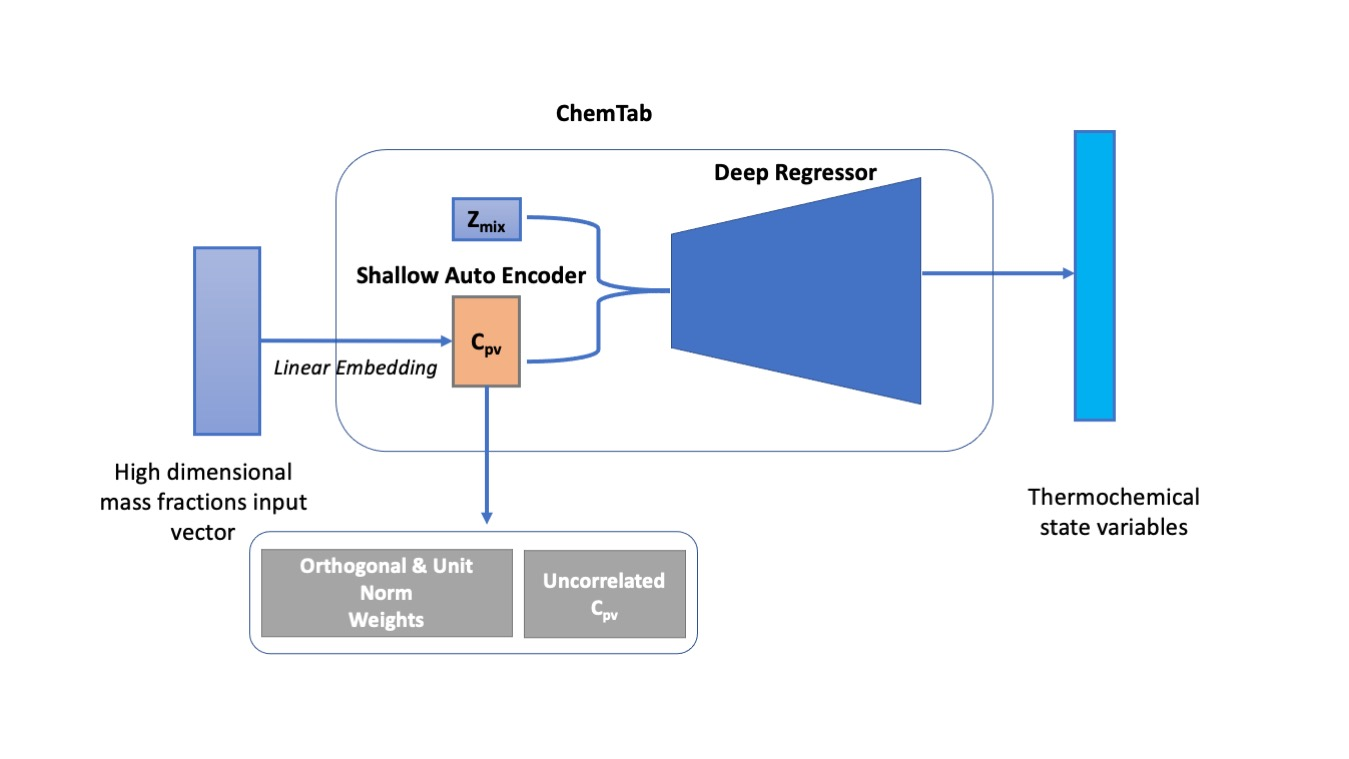

## ChemTab Implementation Formulation

### Overall Network

\begin{equation}\label{eqn:DNN}
    \begin{aligned}
      f_{\mathcal{\theta}}(y) = W^{[L-1]}\mathcal{\sigma} \: \mathcal{\rm o} \: (W^{[L−2]}\mathcal{\sigma} \: \mathcal{\rm o} \: (\dots(W^{[1]}\mathcal{\sigma} \: \mathcal{\rm o} \: (W^{[0]}y + b^{[0]}) + b^{[1]})\dots) + b\\
     \textrm{where,} \quad W^{[l]} \in R^{m_{l+1} \: \times \: m_{l}}\\
      b^{[l]} = R^{m_{l+1}}\\
      m_{0} = d_{in} = d\\
      m_{L} = d_{out}\\
      \mathcal{\sigma} \: \textrm{is a scalar/activation function}\\ 
      \mathcal{\rm o} \: \textrm{is an entry-wise operation}\\
      m \: \textrm{is the number of neurons}\\
      in = s \times n\\
      s = \textrm{the number of species in the mechanism}\\
      n = \textrm{the number of data points (no. of flames * axial coordinate range)}\\
      out = \textrm{no. of thermo-chemical variables  }\mathcal{S}\\
    \end{aligned}
\end{equation}

### Layer Specifics
\begin{equation}\label{eqn:DNN-expansion}
    \begin{aligned}
    f_{\mathcal{\theta}}^{[0]}(y) = y \\
    f_{\mathcal{\theta}}^{[1]}(y) = (W^{[0]} f_{\mathcal{\theta}}^{[0]}(y)) \\
    f_{\mathcal{\theta}}^{[l]}(y) = \mathcal{\sigma} \: \mathcal{\rm o} \: (W^{[l−1]} f_{\mathcal{\theta}}^{[l-1]}(y) \:+\: b^{[l-1]} ) \:\:\:  2 \geq l \leq L-1  \\
    f_{\mathcal{\theta}}(y) = f_{\mathcal{\theta}}^{[L]}(y) = \mathcal{\sigma} \: \mathcal{\rm o} \: (W^{[L-1]} f_{\mathcal{\theta}}^{[L-1]}(y) \:+\: b^{[L-1]} ) 
    \end{aligned}
\end{equation}

### Optimization Specifics
\begin{equation}\label{eqn:ChemTab-Constraints}
    \begin{aligned}
        \arg\min_{\mathcal{\theta}} \quad \lvert f_{\mathcal{\theta}}(y) - \mathcal{S} \rvert\\
        s.t. \quad W^{[0]T}W^{[0]} = I\\
        \Vert W^{[0]} \Vert = 1\\
        f_{\mathcal{\theta}}^{[1]}(y)^Tf_{\mathcal{\theta}}^{[1]}(y) = I\\
        \textrm{where,} \quad f_{\mathcal{\theta}}(y) \quad \textrm{is regressor's prediction}\\
        \mathcal{S} \quad \textrm{is true thermo-chemical state variables}
    \end{aligned}
\end{equation}


## Ensembles

### CT-PVG(ALL)-DNN
#### Constrained DNN -- Baseline (Zmix + 4 Dim Linear Embedding; All Constraints)

In [17]:

  
def getLinearEncoder(model):
    model_layers = {layer.name: layer for layer in model.layers}
    linear_encoder_model = model_layers['linear_embedding'] # this 'layer' is actually a bonafied model
    linear_encoder_model.summary()

    return linear_encoder_model

def getRegressor(model):
    model_layers = {layer.name: layer for layer in model.layers}
    regressor_model = model_layers['prediction'] # unfortunately regressor is named this for compatibility with older code
    regressor_model.summary()

    return regressor_model

    
def getIntermediateLayers(x):
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dense(32, activation="relu")(x)
    return x

def getLinearLayerConcatenatedWithZmix(x,Zmix,noOfInputNeurons,noOfCpv,kernel_constraint='Y',kernel_regularizer='Y',activity_regularizer='Y'):
    if kernel_constraint=='Y'and kernel_regularizer =='N':
        x = layers.Dense(noOfCpv,use_bias=False, name="linear_embedding", activation="linear",\
                                                             kernel_constraint=UnitNorm(axis=0))(x)

    elif kernel_constraint=='N'and kernel_regularizer =='Y':
        x = layers.Dense(noOfCpv,use_bias=False, name="linear_embedding", activation="linear",\
                         kernel_regularizer=WeightsOrthogonalityConstraint(noOfCpv, weightage=1., axis=0))(x)

    elif kernel_constraint=='N'and kernel_regularizer =='N' :
        x = layers.Dense(noOfCpv,use_bias=False, name="linear_embedding", activation="linear")(x)

    elif kernel_constraint=='Y'and kernel_regularizer =='Y':
        x = layers.Dense(noOfCpv,use_bias=False, name="linear_embedding", activation="linear",\
                kernel_constraint=UnitNorm(axis=0),\
                         kernel_regularizer=WeightsOrthogonalityConstraint(noOfCpv, weightage=1., axis=0))(x)
    
    if activity_regularizer =='Y':
        #Concatenate the Linear Embedding and Zmix together
        x = layers.Concatenate(activity_regularizer=UncorrelatedFeaturesConstraint(encoding_dim+1, weightage=1.))([Zmix, x])
    else:
        x = layers.Concatenate()([Zmix, x])
        
    return x    


def get_layer_constraints(noOfCpv,kernel_constraint='Y',kernel_regularizer='Y',activity_regularizer='Y'):
    layer_constraints = {}
    if kernel_constraint=='Y':
        layer_constraints['kernel_constraint'] = UnitNorm(axis=0)
    if kernel_regularizer =='Y':
        layer_constraints['kernel_regularizer'] = WeightsOrthogonalityConstraint(noOfCpv, weightage=1., axis=0)
    if activity_regularizer =='Y':
        layer_constraints['activity_regularizer'] = UncorrelatedFeaturesConstraint(noOfCpv, weightage=1.)
    return layer_constraints

def addLinearModel(inputs, noOfInputNeurons, noOfCpv, concatenateZmix='Y', kernel_constraint='Y',\
                                                       kernel_regularizer='Y',activity_regularizer='Y'):
    # make into boolean
    concatenateZmix=concatenateZmix=='Y'

    # the [1] is really important because that skips the extra (batch)
    # dimension that keras adds implicitly
    assert noOfInputNeurons == inputs[0].shape[1]

    # get constraints and extract activity regularizer for concat layer!
    contraints = get_layer_constraints(noOfCpv,kernel_constraint,kernel_regularizer,activity_regularizer)
    
    if concatenateZmix:
        try:
            activity_regularizer = contraints['activity_regularizer']
            del contraints['activity_regularizer']
        except KeyError:
            activity_regularizer=None

    # here we only use kernel_regularizer & kernel_constraint constraints, activity regularizer is saved for concat layer to work with zmix
    output = layers.Dense(noOfCpv, name="linear_embedding", activation="linear", **contraints)(inputs[0]) #self.getLinearLayer(noOfInputNeurons, noOfCpv)(inputs[0])
    linear_emb_model = keras.models.Model(inputs=inputs[0], outputs=output, name="linear_embedding")
    output = linear_emb_model(inputs[0]) 

    # implicitly if there are 2 input layers then we want to add mix
    assert concatenateZmix == (len(inputs)>1)

    concat_list = [output]
    if concatenateZmix:
        zmix = inputs[1]
        concat_list = [zmix] + concat_list # best model seperator maybe assuming that zmix comes first here...
        output = layers.Concatenate(name="concatenated_CPVs", activity_regularizer=activity_regularizer)(concat_list)

    #Concatenate the Linear Embedding and Zmix together
    return output

def addRegressorModel(x,concatenateZmix, num_outputs):
    
    # the [1:] is really important because that removes the extra (batch)
    # dimension that keras adds implicitly
    
    _input = layers.Input(shape=(x.shape[1],), name='input_1')
    # # This is the simple baseline model architecture:
    layer_sizes = [32,64,128,256,512,256,128,64,32]
    output = _input
    for size in layer_sizes:
        output = layers.Dense(size, activation='relu')(output)
        # used to be named 'prediction' (now model is named 'prediction', since it is last layer)
        souener_pred = layers.Dense(num_outputs)(output)
        regressor_model=keras.models.Model(inputs=_input, outputs=souener_pred, name='prediction')

    return regressor_model(x)

In [18]:
def evaluate_model(model,dataset,model_type='encoder_regressor',evaluation_type='test'):
    
    if model_type =='encoder_regressor':
        if evaluation_type =='test':
            Zmix_test =  dataset["Zmix_test"]
            normalized_species_test = dataset["normalized_species_test"]
            predictions = model.predict([normalized_species_test,Zmix_test])
        #assuming this is the 'complete' data set evaluation
        else:
            Zmix_all =  dataset["Zmix_all"]
            normalized_species_all = dataset["normalized_species_test"]
            predictions = model.predict([normalized_species_all,Zmix_all])
    else:
        if evaluation_type =='test':
            cpvs_zmix_test = dataset["cpvs_zmix_test"]
            predictions = model.predict(cpvs_zmix_test)
        #assuming this is the 'complete' data set evaluation
        else:
            cpvs_zmix_all = dataset["cpvs_zmix_all"]
            predictions = model.predict(cpvs_zmix_all)
    
    if evaluation_type =='test':
        Y_true_df = pd.DataFrame(data=dataset["Y_test"],  columns=dependents)
    else:
        Y_true_df = pd.DataFrame(data=dataset["Y_all"],  columns=dependents)
    
    scaler_souener = dataset["scaler_souener"]
    
    Y_pred = scaler_souener.inverse_transform(predictions)
    
    Y_pred_df = pd.DataFrame(data=Y_pred,  columns=dependents)
    
    err_df = computeErrorAcrossDependents(Y_pred_df, Y_true_df)
    
    return err_df,Y_true_df,Y_pred_df
    
    
def addLinearEncodedProgVarsToDataSet(linear_encoder_model,dataset):
    dataset["cpvs_test"] = linear_encoder_model.predict(dataset["normalized_species_test"])
    dataset["cpvs_train"] = linear_encoder_model.predict(dataset["normalized_species_train"])
    dataset["cpvs_zmix_train"] = np.append(np.reshape(dataset["Zmix_train"], (-1, 1)),dataset["cpvs_train"],axis=1)
    dataset["cpvs_zmix_test"] = np.append(np.reshape(dataset["Zmix_test"], (-1, 1)),dataset["cpvs_test"],axis=1)
    dataset["cpvs_all"] = linear_encoder_model.predict(dataset["normalized_species_all"])
    dataset["cpvs_zmix_all"] = np.append(np.reshape(dataset["Zmix_all"], (-1, 1)),dataset["cpvs_all"],axis=1)
    return dataset

In [19]:

'''
species_inputs = keras.Input(shape=(53,), name="species_input")

Zmix = keras.Input(shape=(1,), name="Zmix")

x = getLinearLayerConcatenatedWithZmix(species_inputs,Zmix,encoding_dim,encoding_dim,kernel_constraint='Y',\
                                       kernel_regularizer='Y',activity_regularizer='Y')
x = getIntermediateLayers(x)

#Predict the source energy
souener_pred = layers.Dense(noOfOutputNeurons, name="prediction")(x)

model = keras.Model(
    inputs=[species_inputs,Zmix],
    outputs=[souener_pred],
)

'''


''''''''''''''''''''
#New Way
''''''''''''''''''''
concatenateZmix = 'Y'
noOfInputNeurons = 53
noOfOutputNeurons = 8
noOfCpv = 4
kernel_constraint = 'Y'
kernel_regularizer = 'Y'
activity_regularizer = 'Y'

#The following 2 lines make up the Auto-encoder
species_inputs = keras.Input(shape=(noOfInputNeurons,), name="species_input")

#Build the regressor
if concatenateZmix == 'Y':
    zmix = keras.Input(shape=(1,), name="zmix")
    inputs = [species_inputs,zmix]
else:
    inputs = [species_inputs]

x = addLinearModel(inputs, noOfInputNeurons, noOfCpv,concatenateZmix=concatenateZmix,\
                   kernel_constraint=kernel_constraint,kernel_regularizer=kernel_regularizer,activity_regularizer=activity_regularizer)


souener_pred = addRegressorModel(x,concatenateZmix, noOfOutputNeurons)
model = keras.Model(inputs=inputs,outputs=souener_pred)


2022-05-21 12:11:07.590872: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN)to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-05-21 12:11:07.744418: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fd217088bf0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2022-05-21 12:11:07.744440: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version


In [20]:
'''
tf.keras.utils.plot_model(model,to_file="model.png",
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False,
    dpi=96)
'''

'\ntf.keras.utils.plot_model(model,to_file="model.png",\n    show_shapes=True,\n    show_layer_names=True,\n    rankdir="TB",\n    expand_nested=False,\n    dpi=96)\n'

In [21]:
model.compile(loss='mean_absolute_error',optimizer=tf.keras.optimizers.Adam(0.001))

In [22]:
model.summary()

Model: "functional_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
species_input (InputLayer)      [(None, 53)]         0                                            
__________________________________________________________________________________________________
zmix (InputLayer)               [(None, 1)]          0                                            
__________________________________________________________________________________________________
linear_embedding (Functional)   (None, 4)            216         species_input[0][0]              
__________________________________________________________________________________________________
concatenated_CPVs (Concatenate) (None, 5)            0           zmix[0][0]                       
                                                                 linear_embedding[0][0]

In [26]:
#getDataSet(ipscaler="MinMaxScaler",opscaler="MinMaxScaler", split_strategy="points", train_portion=0.8)
split_strategy="flames"
train_portion=0.8
dataset = getDataSet(split_strategy=split_strategy,train_portion=train_portion)

train_set_keys:  [25034, 15777, 32353, 23782, 2134, 3217, 7694, 2903, 14989, 3056, 21463, 11018, 8974, 10467, 3386, 20390, 5373, 9446, 3949, 3564, 18402, 6944, 30735, 12208, 3752, 14239, 2620, 2758, 2246, 4849, 2364, 9944, 2027, 4376, 13527, 5104, 7309, 16608, 12851, 5656, 6267, 8099, 27738, 4157]
test_set_keys:  [17482, 2489, 5953, 8525, 11598, 19371, 29198, 6597, 26352, 22593, 4606]
train:  [32353 30735 27738 25034 23782]
test:  [29198 26352 22593 19371 17482]


In [33]:
%%time

normalized_species_train = dataset["normalized_species_train"]
Zmix_train = dataset["Zmix_train"] 
normalized_souener_train = dataset["normalized_souener_train"]

history = model.fit([normalized_species_train,Zmix_train], 
                          normalized_souener_train,
                          validation_split=0.2,
                          verbose=0, 
                          epochs=100, 
                          callbacks=[es])

Epoch 00049: early stopping
CPU times: user 2min 3s, sys: 43.6 s, total: 2min 46s
Wall time: 42.1 s


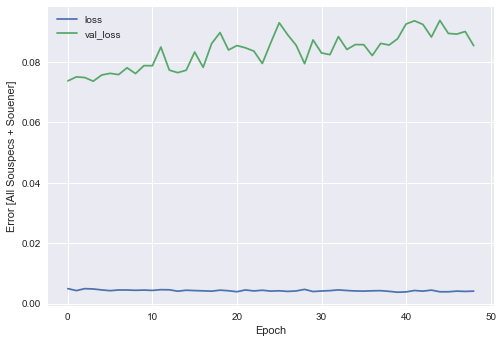

In [34]:
plot_loss(history)

In [35]:
err_df,Y_true_df,Y_pred_df = evaluate_model(model,dataset,model_type='encoder_regressor',evaluation_type='test')

In [36]:
err_df

,Dependent,Mean ABS,Total ABS,#Pts
0,souener,2.390641e+09,7.862819e+12,3289
1,souspecO2,7.614887e+02,2.504536e+06,3289
2,souspecCO,5.408012e+02,1.778695e+06,3289
3,souspecCO2,5.789108e+01,1.904038e+05,3289
4,souspecH2O,1.792300e+02,5.894875e+05,3289
5,souspecOH,1.663385e+02,5.470874e+05,3289
6,souspecH2,2.617136e+01,8.607760e+04,3289
7,souspecCH4,1.906412e+02,6.270189e+05,3289


In [37]:
error_dict['CT_PVG(ALL)_DNN'] =  err_df.values[0][1]#souener, MEAN_ABS_ERR 

/Users/asalunkh/source_code/ChemTab/ChemTab/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:>

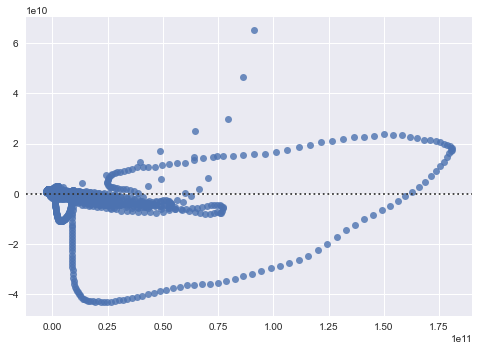

In [38]:
sns.residplot(Y_true_df["souener"].values, getResiduals(Y_true_df["souener"].values,Y_pred_df["souener"].values))

## Separate out the Encoder & Regressor

In [39]:
linear_encoder_model = getLinearEncoder(model)
regressor_model =   getRegressor(model)

Model: "linear_embedding"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
species_input (InputLayer)   [(None, 53)]              0         
_________________________________________________________________
linear_embedding (Dense)     (None, 4)                 216       
Total params: 216
Trainable params: 216
Non-trainable params: 0
_________________________________________________________________
Model: "prediction"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 5)]               0         
_________________________________________________________________
dense (Dense)                (None, 32)                192       
_________________________________________________________________
dense_2 (Dense)              (None, 64)                2112      
________________________________

### Save the Encoder


In [46]:
filename = 'saved_models/encoder_flames.h5'
linear_encoder_model.save(filename)

### Add the encoded data to the dataset

In [43]:
dataset = addLinearEncodedProgVarsToDataSet(linear_encoder_model,dataset)

### Save the dataset

In [44]:
import pickle
filename = 'uqdataset_flames'+'_' + split_strategy + '_' + str (train_portion)
outfile = open(filename,'wb')
pickle.dump(dataset,outfile)
outfile.close()


### Save the Regressor

In [45]:
filename = 'saved_models/regressor_flames.h5'
regressor_model.save(filename)